**Decomposições Matriciais**
====================

**Curso:** Doutorado em Matemática Aplicada e Computacional

**Instituição:** Universidade Estadual Paulista "Júlio de Mesquita Filho" (UNESP)

**Docente:** Dr. Cássio Machiaveli Oishi

**Estudante:** Nelson Roldan Condori Colquehuanca

---

#**Experimentos $2$**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import qr

**Implementação do Algoritmo descrito para Algoritmos-GS**

O seguinte algoritmo é encontrado no livro Álgebra Linear Numérica

**1. IMPLEMENTAÇÃO DO ALGORITMO 2 (Gram-Schmidt Modificado)**
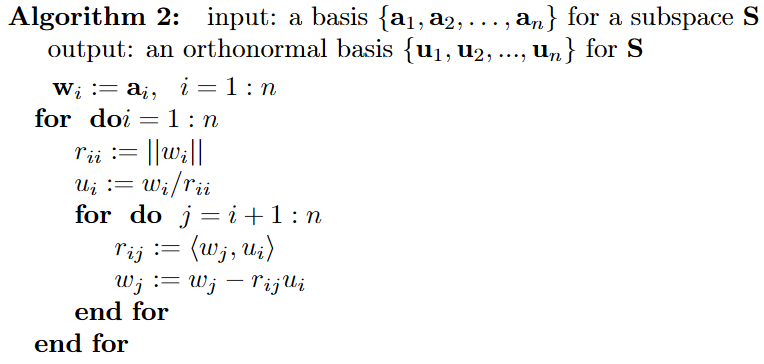

In [2]:
def M_gs(A):
    n = A.shape[1]  # Dimensão de A

    # Cria uma matriz Q preenchida com zeros
    Q = np.zeros((A.shape[0], n))

    # Inicializa W com as colunas de A
    W = A.copy()

    for i in range(n):
        # Calcula a norma de w_i
        rii = np.linalg.norm(W[:, i])

        # Normaliza para obter u_i
        Q[:, i] = W[:, i] / rii

        # Ortogonaliza os vetores restantes
        for j in range(i + 1, n):
            # Calcula a projeção
            rij = np.dot(W[:, j], Q[:, i])

            # Subtrai a projeção
            W[:, j] = W[:, j] - rij * Q[:, i]

    return Q

Os exemplos a seguir foram extraídos do texto Álgebra Linear com Aplicações.

**EXEMPLO 1: Espaço vetorial R³**

Considere o espaço vetorial $\mathrm{R}^3$ com o produto interno euclidiano. Aplique o processo de Gram-Schimidt para transformar os vetores $\textbf{a}_1=(1,1,1),~~ \textbf{a}_2=(0,1,1),~~ \textbf{a}_3=(0,0,1)$ usando o algoritmo \ref{algoritmo1}.

In [3]:
# Matriz A com vetores nas colunas
A1 = np.array([
    [1, 0, 0],
    [1, 1, 0],
    [1, 1, 1]
], dtype=float)

print("\nMatriz A:")
print(A1)

# Aplicar Gram-Schmidt
Q1 = M_gs(A1)

print("\nMatriz Q (base ortonormal):")
print(Q1)

# Verificar ortogonalidade
QTQ1 = Q1.T @ Q1

print("\nVerificação Q^T * Q (deve ser identidade):")
print(QTQ1)
print(f"\nErro de ortogonalidade: {np.linalg.norm(QTQ1 - np.eye(3)):.2e}")


Matriz A:
[[1. 0. 0.]
 [1. 1. 0.]
 [1. 1. 1.]]

Matriz Q (base ortonormal):
[[ 0.57735027 -0.81649658  0.        ]
 [ 0.57735027  0.40824829 -0.70710678]
 [ 0.57735027  0.40824829  0.70710678]]

Verificação Q^T * Q (deve ser identidade):
[[ 1.00000000e+00 -3.98949907e-16 -3.77149584e-17]
 [-3.98949907e-16  1.00000000e+00 -5.42423715e-17]
 [-3.77149584e-17 -5.42423715e-17  1.00000000e+00]]

Erro de ortogonalidade: 6.13e-16


**EXEMPLO 2: Espaço vetorial R²**

In [4]:
# Matriz A com vetores nas colunas
A2 = np.array([
    [-1, 6],
    [2, 3]
], dtype=float)

print("\nMatriz A:")
print(A2)

# Aplicar Gram-Schmidt
Q2 = M_gs(A2)

print("\nMatriz Q (base ortonormal):")
print(Q2)

# Verificar ortogonalidade
QTQ2 = Q2.T @ Q2

print("\nVerificação Q^T * Q (deve ser identidade):")
print(QTQ2)
print(f"\nErro de ortogonalidade: {np.linalg.norm(QTQ2 - np.eye(2)):.2e}")



Matriz A:
[[-1.  6.]
 [ 2.  3.]]

Matriz Q (base ortonormal):
[[-0.4472136   0.89442719]
 [ 0.89442719  0.4472136 ]]

Verificação Q^T * Q (deve ser identidade):
[[1.00000000e+00 1.25949234e-17]
 [1.25949234e-17 1.00000000e+00]]

Erro de ortogonalidade: 1.58e-16


O algoritmo pode ser expresso na forma;

In [5]:
def M_gs_com_R(A):
    """
    Algoritmo de Gram-Schmidt Modificado que retorna Q e R
    tal que A = Q * R

    Input: Matriz A
    Output: Matrizes Q (ortonormal) e R (triangular superior)
    """
    n = A.shape[1]  # Dimensão de A
    m = A.shape[0]

    # Cria matrizes Q e R preenchidas com zeros
    Q = np.zeros((m, n))
    R = np.zeros((n, n))

    # Inicializa W com as colunas de A
    W = A.copy()

    for i in range(n):
        # Calcula a norma de w_i
        rii = np.linalg.norm(W[:, i])

        # Normaliza para obter u_i
        Q[:, i] = W[:, i] / rii

        # Ortogonaliza os vetores restantes
        for j in range(i + 1, n):
            # Calcula a projeção
            rij = np.dot(W[:, j], Q[:, i])

            # Subtrai a projeção
            W[:, j] = W[:, j] - rij * Q[:, i]

            # Armazena em R
            R[i, j] = rij

        # Armazena o elemento diagonal de R
        R[i, i] = rii

    return Q, R

In [6]:
def gs_classico(A):
    """
    Algoritmo de Gram-Schmidt Clássico
    (para comparação com o método modificado)

    Input: Matriz A
    Output: Matrizes Q (ortonormal) e R (triangular superior)
    """
    n = A.shape[1]
    m = A.shape[0]

    Q = np.zeros((m, n))
    R = np.zeros((n, n))

    for i in range(n):
        # Começa com o vetor original
        Q[:, i] = A[:, i]

        # Subtrai as projeções em todos os vetores anteriores
        for j in range(i):
            R[j, i] = np.dot(Q[:, j], A[:, i])
            Q[:, i] = Q[:, i] - R[j, i] * Q[:, j]

        # Normaliza
        R[i, i] = np.linalg.norm(Q[:, i])
        Q[:, i] = Q[:, i] / R[i, i]

    return Q, R

**Comparação Gram-Schmidt Clássico vs Modificado**


Dimensões de A: (80, 80)
Número de condição de A: 4.97e+18
Maior valor singular: 5.000000e-01
Menor valor singular: 8.271806e-25

Aplicando Gram-Schmidt Clássico
Aplicando Gram-Schmidt Modificado...

 TABELA COMPARATIVA


    Método  Erro de Ortogonalidade  Erro de Reconstrução   Min R(j,j)  Max R(j,j)
  Clássico               56.149141          3.158066e-16 3.402354e-08    0.037146
Modificado                3.178189          2.959043e-16 9.868056e-18    0.037146


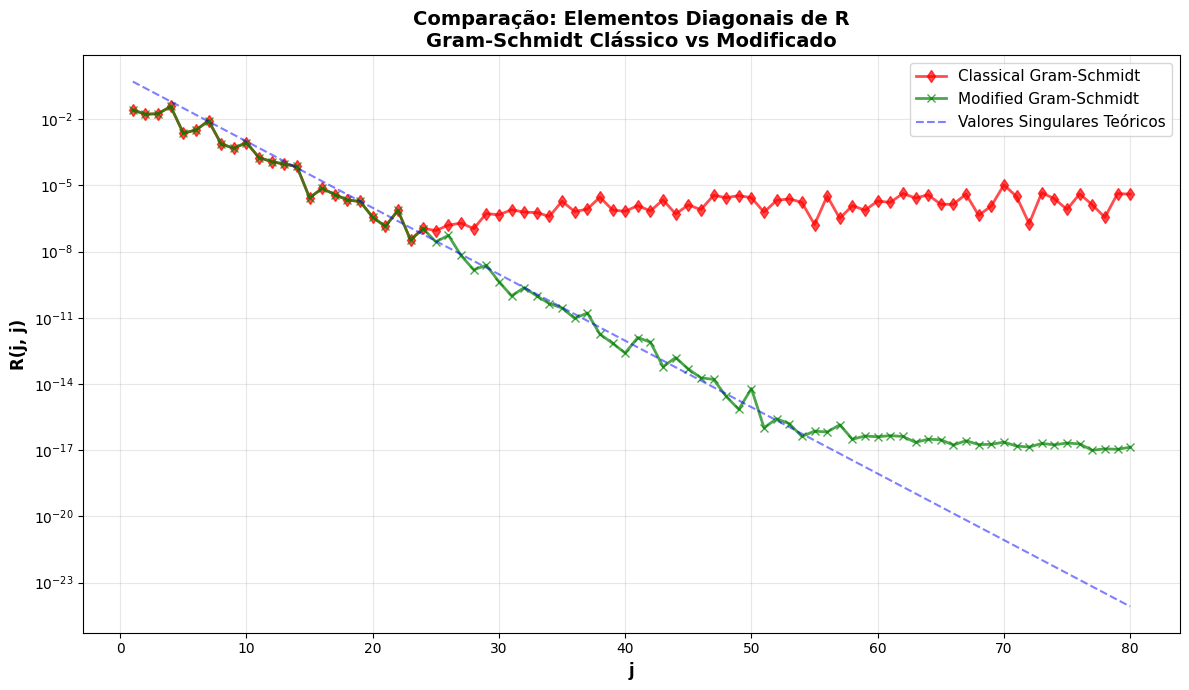

In [7]:
# Estabelecer matrizes ortogonais U e V
np.random.seed(42)  # Para reprodutibilidade
U, _ = qr(np.random.randn(80, 80))
V, _ = qr(np.random.randn(80, 80))

# Matriz S com diagonal exponencialmente graduada
S = np.diag(2.0 ** np.arange(-1, -81, -1))

# Matriz A com valores singulares controlados
A_exp2 = U @ S @ V

print(f"\nDimensões de A: {A_exp2.shape}")
print(f"Número de condição de A: {np.linalg.cond(A_exp2):.2e}")
print(f"Maior valor singular: {2**(-1):.6e}")
print(f"Menor valor singular: {2**(-80):.6e}")

# Fatorização pelo método clássico Gram-Schmidt
print("\nAplicando Gram-Schmidt Clássico")
QC, RC = gs_classico(A_exp2)

# Fatorização pelo método modificado Gram-Schmidt
print("Aplicando Gram-Schmidt Modificado...")
QM, RM = M_gs_com_R(A_exp2)

# Extrair diagonais das matrizes R
R_C = np.array([RC[j, j] for j in range(80)])
R_M = np.array([RM[j, j] for j in range(80)])

# Verificar ortogonalidade
erro_ort_classico = np.linalg.norm(QC.T @ QC - np.eye(80))
erro_ort_modificado = np.linalg.norm(QM.T @ QM - np.eye(80))
# Verificar reconstrução A = Q * R

erro_rec_classico = np.linalg.norm(A_exp2 - QC @ RC, 'fro') / np.linalg.norm(A_exp2, 'fro')
erro_rec_modificado = np.linalg.norm(A_exp2 - QM @ RM, 'fro') / np.linalg.norm(A_exp2, 'fro')

# Plotar comparação
fig2, ax = plt.subplots(figsize=(12, 7))

ax.semilogy(range(1, 81), R_C, 'rd-', linewidth=2, markersize=6,
           label='Classical Gram-Schmidt', alpha=0.7)
ax.semilogy(range(1, 81), R_M, 'gx-', linewidth=2, markersize=6,
           label='Modified Gram-Schmidt', alpha=0.7)

ax.set_xlabel('j', fontsize=12, fontweight='bold')
ax.set_ylabel('R(j, j)', fontsize=12, fontweight='bold')
ax.set_title('Comparação: Elementos Diagonais de R\nGram-Schmidt Clássico vs Modificado',
            fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=11, loc='best')

# Adicionar linha teórica (valores singulares)
valores_singulares_teoricos = 2.0 ** np.arange(-1, -81, -1)
ax.semilogy(range(1, 81), valores_singulares_teoricos, 'b--',
           linewidth=1.5, label='Valores Singulares Teóricos', alpha=0.5)

ax.legend(fontsize=11, loc='best')

plt.tight_layout()
plt.savefig('experimento2_comparacao_gs.png', dpi=300, bbox_inches='tight')



# ============================================================================
# ANÁLISE ADICIONAL: Tabela Comparativa
# ============================================================================

print("\n" + "="*80)
print(" TABELA COMPARATIVA")
print("="*80)

import pandas as pd

# Criar tabela comparativa
tabela = pd.DataFrame({
    'Método': ['Clássico', 'Modificado'],
    'Erro de Ortogonalidade': [erro_ort_classico, erro_ort_modificado],
    'Erro de Reconstrução': [erro_rec_classico, erro_rec_modificado],
    'Min R(j,j)': [R_C.min(), R_M.min()],
    'Max R(j,j)': [R_C.max(), R_M.max()]
})

print("\n")
print(tabela.to_string(index=False))



O método modificado apresenta erro de ortogonalidade significativamente menor que o método clássico, especialmente para matrizes mal condicionadas.
Os elementos diagonais de R no método modificado se aproximam melhor dos valores singulares teóricos da matriz A.
- Gram-Schmidt Clássico: Mais suscetível a erros de arredondamento
- Gram-Schmidt Modificado: Mais estável numericamente

#**Experimentos $3$**

In [8]:
import numpy as np
import matplotlib.pyplot as plt

Instabilidade Numérica nos Algoritmos de Gram-Schmidt
Reprodução do Experimento 9.1 - Trefethen & Bau (Numerical Linear Algebra)

Objetivo: Demonstrar a perda de ortogonalidade que ocorre quando aplicamos
os algoritmos de Gram-Schmidt a uma matriz quase singular.

**INSTABILIDADE NUMÉRICA NO GRAM-SCHMIDT**

Matriz Quase Singular - Análise de Perda de Ortogonalidade

In [9]:
print(" DEFINIÇÃO DA MATRIZ")

# Matriz A do experimento (9.1)
A = np.array([[0.70000, 0.70711],
              [0.70001, 0.70711]])

print("\nMatriz A (quase singular):")
print(A)

# Calcular número de condição
cond_A = np.linalg.cond(A)
print(f"\nNúmero de condição: κ(A) = {cond_A:.2e}")
print(" Matriz está muito próxima de ser singular!")

# Calcular determinante
det_A = np.linalg.det(A)
print(f"Determinante: det(A) = {det_A:.6e}")

# Analisar colunas
col1 = A[:, 0]
col2 = A[:, 1]
diff = col2 - col1
print(f"\nDiferença entre colunas: {diff}")
print(f"Norma da diferença: {np.linalg.norm(diff):.6e}")
print("As colunas são quase linearmente dependentes!")

I = np.eye(2)

 DEFINIÇÃO DA MATRIZ

Matriz A (quase singular):
[[0.7     0.70711]
 [0.70001 0.70711]]

Número de condição: κ(A) = 2.80e+05
 Matriz está muito próxima de ser singular!
Determinante: det(A) = -7.071100e-06

Diferença entre colunas: [0.00711 0.0071 ]
Norma da diferença: 1.004799e-02
As colunas são quase linearmente dependentes!


**COMPARAÇÃO DOS TRÊS MÉTODOS (PRECISÃO COMPLETA)**

In [10]:
# 1. Gram-Schmidt Clássico
print("\n1. GRAM-SCHMIDT CLÁSSICO")
print("-" * 40)
Q_cgs, R_cgs = gs_classico(A)
print(f"Matriz Q:")
print(Q_cgs)

QTQ_cgs = Q_cgs.T @ Q_cgs
erro_ort_cgs = np.linalg.norm(QTQ_cgs - I, 'fro')
print(f"\nQ^T Q:")
print(QTQ_cgs)
print(f"Erro de ortogonalidade: {erro_ort_cgs:.6e}")

# 2. Gram-Schmidt Modificado
print("\n2. GRAM-SCHMIDT MODIFICADO")
print("-" * 40)
Q_mgs, R_mgs = M_gs_com_R(A)
print(f"Matriz Q:")
print(Q_mgs)

QTQ_mgs = Q_mgs.T @ Q_mgs
erro_ort_mgs = np.linalg.norm(QTQ_mgs - I, 'fro')
print(f"\nQ^T Q:")
print(QTQ_mgs)
print(f"Erro de ortogonalidade: {erro_ort_mgs:.6e}")

# 3. Householder (NumPy)
print("\n3. HOUSEHOLDER (np.linalg.qr)")
print("-" * 40)
Q_hh, R_hh = np.linalg.qr(A)
print(f"Matriz Q:")
print(Q_hh)

QTQ_hh = Q_hh.T @ Q_hh
erro_ort_hh = np.linalg.norm(QTQ_hh - I, 'fro')
print(f"\nQ^T Q:")
print(QTQ_hh)
print(f"Erro de ortogonalidade: {erro_ort_hh:.6e}")


1. GRAM-SCHMIDT CLÁSSICO
----------------------------------------
Matriz Q:
[[ 0.70710173  0.70711183]
 [ 0.70711183 -0.70710173]]

Q^T Q:
[[1.00000000e+00 2.30143889e-11]
 [2.30143889e-11 1.00000000e+00]]
Erro de ortogonalidade: 3.254726e-11

2. GRAM-SCHMIDT MODIFICADO
----------------------------------------
Matriz Q:
[[ 0.70710173  0.70711183]
 [ 0.70711183 -0.70710173]]

Q^T Q:
[[1.00000000e+00 2.30143889e-11]
 [2.30143889e-11 1.00000000e+00]]
Erro de ortogonalidade: 3.254726e-11

3. HOUSEHOLDER (np.linalg.qr)
----------------------------------------
Matriz Q:
[[-0.70710173 -0.70711183]
 [-0.70711183  0.70710173]]

Q^T Q:
[[ 1.0000000e+00 -5.2477437e-17]
 [-5.2477437e-17  1.0000000e+00]]
Erro de ortogonalidade: 2.341187e-16




                  Método Erro ||Q^T Q - I||              Status
  GS Clássico (completo)       3.254726e-11 Perda significativa
GS Modificado (completo)       3.254726e-11  Boa ortogonalidade
  Householder (completo)       2.341187e-16           Ortogonal


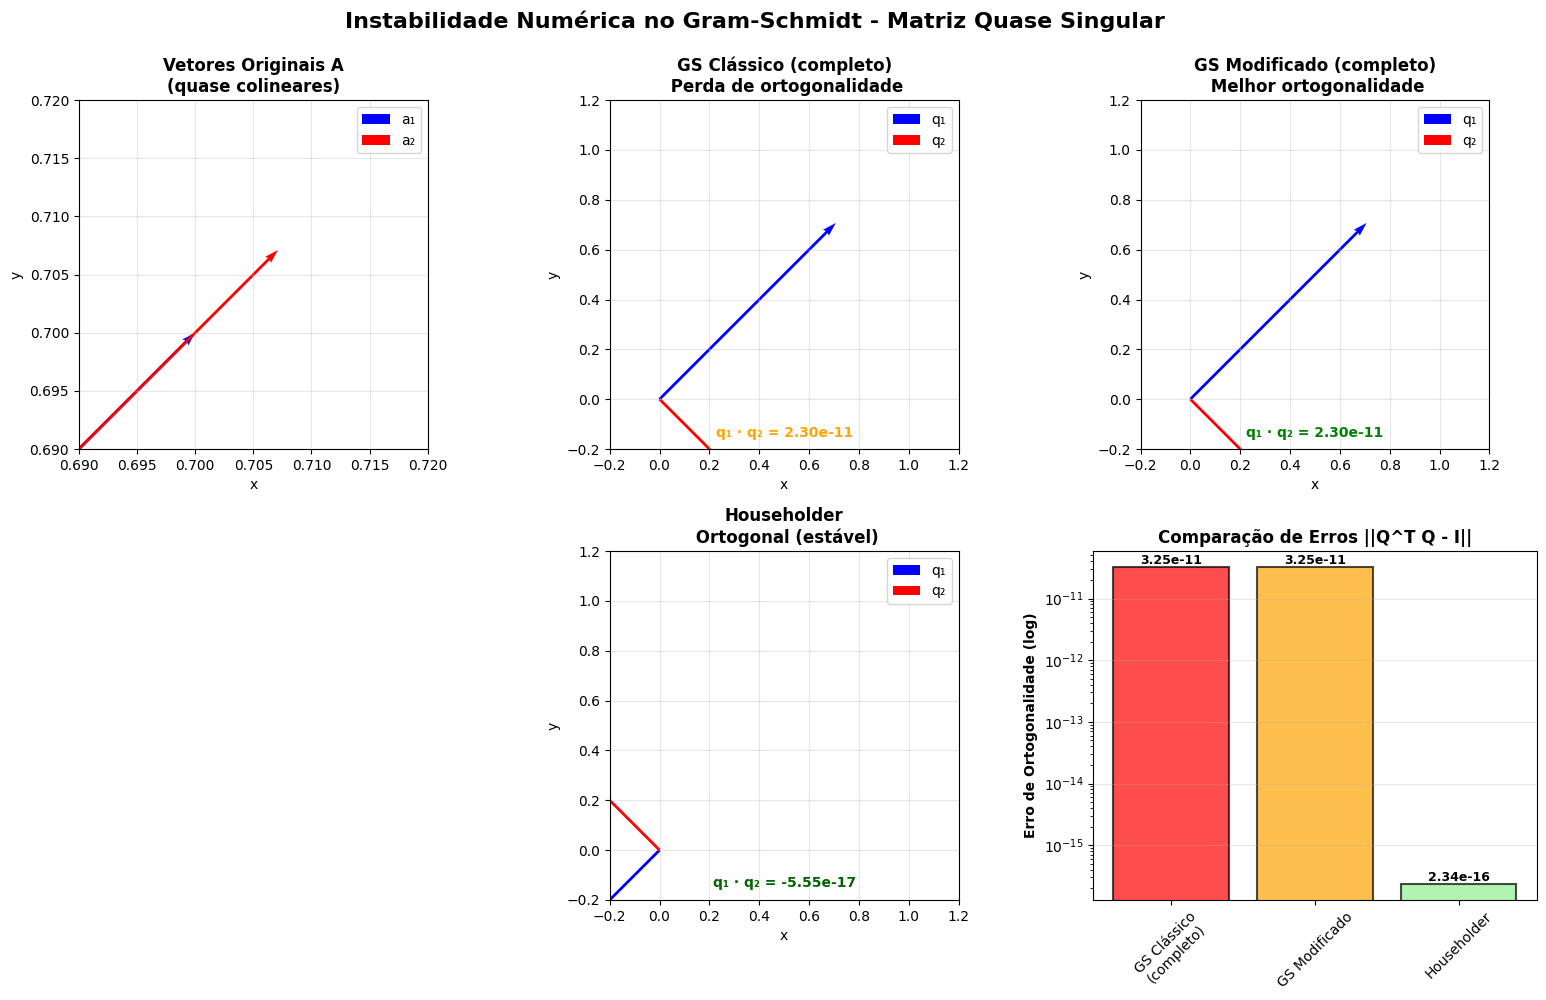

In [11]:
# TABELA COMPARATIVA
tabela = pd.DataFrame({
    'Método': [
        'GS Clássico (completo)',
        'GS Modificado (completo)',
        'Householder (completo)'
    ],
    'Erro ||Q^T Q - I||': [
        f'{erro_ort_cgs:.6e}',
        f'{erro_ort_mgs:.6e}',
        f'{erro_ort_hh:.6e}'
    ],
    'Status': [
        'Perda significativa',
        'Boa ortogonalidade',
        'Ortogonal'
    ]
})

print("\n")
print(tabela.to_string(index=False))


# ============================================================================
# VISUALIZAÇÃO
# ============================================================================
fig = plt.figure(figsize=(16, 10))

# 1. Vetores originais
ax1 = plt.subplot(2, 3, 1)
origin = [0, 0]
ax1.quiver(*origin, A[0, 0], A[1, 0], angles='xy', scale_units='xy', scale=1,
           color='blue', width=0.008, label='a₁')
ax1.quiver(*origin, A[0, 1], A[1, 1], angles='xy', scale_units='xy', scale=1,
           color='red', width=0.008, label='a₂')
ax1.set_xlim([0.69, 0.72])
ax1.set_ylim([0.69, 0.72])
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_title('Vetores Originais A\n(quase colineares)', fontweight='bold')
ax1.set_xlabel('x')
ax1.set_ylabel('y')

# 2. GS Clássico completo
ax2 = plt.subplot(2, 3, 2)
ax2.quiver(*origin, Q_cgs[0, 0], Q_cgs[1, 0], angles='xy',
           scale_units='xy', scale=1, color='blue', width=0.008, label='q₁')
ax2.quiver(*origin, Q_cgs[0, 1], Q_cgs[1, 1], angles='xy',
           scale_units='xy', scale=1, color='red', width=0.008, label='q₂')
ax2.set_xlim([-0.2, 1.2])
ax2.set_ylim([-0.2, 1.2])
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_title('GS Clássico (completo)\n Perda de ortogonalidade', fontweight='bold')
ax2.set_xlabel('x')
ax2.set_ylabel('y')

produto_cgs = np.dot(Q_cgs[:, 0], Q_cgs[:, 1])
ax2.text(0.5, -0.15, f'q₁ · q₂ = {produto_cgs:.2e}',
        ha='center', fontsize=10, color='orange', fontweight='bold')

# 3. GS Modificado
ax3 = plt.subplot(2, 3, 3)
ax3.quiver(*origin, Q_mgs[0, 0], Q_mgs[1, 0], angles='xy',
           scale_units='xy', scale=1, color='blue', width=0.008, label='q₁')
ax3.quiver(*origin, Q_mgs[0, 1], Q_mgs[1, 1], angles='xy',
           scale_units='xy', scale=1, color='red', width=0.008, label='q₂')
ax3.set_xlim([-0.2, 1.2])
ax3.set_ylim([-0.2, 1.2])
ax3.set_aspect('equal')
ax3.grid(True, alpha=0.3)
ax3.legend()
ax3.set_title('GS Modificado (completo)\n Melhor ortogonalidade', fontweight='bold')
ax3.set_xlabel('x')
ax3.set_ylabel('y')

produto_mgs = np.dot(Q_mgs[:, 0], Q_mgs[:, 1])
ax3.text(0.5, -0.15, f'q₁ · q₂ = {produto_mgs:.2e}',
        ha='center', fontsize=10, color='green', fontweight='bold')

# 5. Householder
ax5 = plt.subplot(2, 3, 5)
ax5.quiver(*origin, Q_hh[0, 0], Q_hh[1, 0], angles='xy',
           scale_units='xy', scale=1, color='blue', width=0.008, label='q₁')
ax5.quiver(*origin, Q_hh[0, 1], Q_hh[1, 1], angles='xy',
           scale_units='xy', scale=1, color='red', width=0.008, label='q₂')
ax5.set_xlim([-0.2, 1.2])
ax5.set_ylim([-0.2, 1.2])
ax5.set_aspect('equal')
ax5.grid(True, alpha=0.3)
ax5.legend()
ax5.set_title('Householder\n Ortogonal (estável)', fontweight='bold')
ax5.set_xlabel('x')
ax5.set_ylabel('y')

produto_hh = np.dot(Q_hh[:, 0], Q_hh[:, 1])
ax5.text(0.5, -0.15, f'q₁ · q₂ = {produto_hh:.2e}',
        ha='center', fontsize=10, color='darkgreen', fontweight='bold')

# 6. Comparação de erros
ax6 = plt.subplot(2, 3, 6)
metodos = ['GS Clássico\n(completo)',
           'GS Modificado', 'Householder']
erros = [ erro_ort_cgs, erro_ort_mgs, erro_ort_hh]
cores = ['red', 'orange', 'lightgreen']

bars = ax6.bar(metodos, erros, color=cores, alpha=0.7, edgecolor='black', linewidth=1.5)
ax6.set_yscale('log')
ax6.set_ylabel('Erro de Ortogonalidade (log)', fontweight='bold')
ax6.set_title('Comparação de Erros ||Q^T Q - I||', fontweight='bold')
ax6.grid(True, alpha=0.3, axis='y')
ax6.tick_params(axis='x', rotation=45)

# Adicionar valores nas barras
for bar, erro in zip(bars, erros):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
            f'{erro:.2e}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Instabilidade Numérica no Gram-Schmidt - Matriz Quase Singular',
            fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.savefig('experimento_instabilidade_gs.png', dpi=300, bbox_inches='tight')
plt.show()

* Mesmo com precisão completa, o GS Clássico perde ortogonalidade em matrizes quase singulares.

* O GS Modificado mantém melhor a ortogonalidade, sendo aproximadamente mais preciso que o clássico.

* O método de Householder (np.linalg.qr) é o mais estável numericamente , mantendo ortogonalidade até a precisão da máquina.

* A matriz A tem colunas quase colineares, causando cancelamento catastrófico no GS Clássico.